# Detección de objetos con YOLO

En este notebook vamos a usar **YOLO** (You Only Look Once), uno de los detectores
de objetos más populares y rápidos. Gracias a la librería **Ultralytics**, podremos
detectar objetos en imágenes y entrenar un modelo con muy pocas líneas de código.

### Qué vamos a hacer
1. Instalar Ultralytics y cargar un modelo YOLO ya entrenado.
2. **Detectar objetos** en imágenes de ejemplo.
3. Entender lo que devuelve el modelo (cajas, clases, confianza).


> **Importante:** activa la GPU en Colab antes de empezar:
> *Entorno de ejecución → Cambiar tipo de entorno → T4 GPU*.
> Con YOLO la GPU es muy recomendable.

## Instalar Ultralytics

La librería `ultralytics` incluye YOLO y todo lo necesario. En Colab se instala
en menos de un minuto.

In [2]:
#pip install ultralytics -q

In [3]:
import os
from pathlib import Path

from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
print('Ultralytics listo')

Ultralytics listo


## Cargar un modelo YOLO ya entrenado

Vamos a cargar `yolo11n.pt`: la versión **nano** de YOLO11 (la más ligera y rápida).
Viene **preentrenada** en el dataset COCO, que tiene 80 categorías de objetos
cotidianos (personas, coches, perros, sillas, móviles, etc.).

> La 'n' es de *nano*. Hay versiones más grandes y precisas (`s`, `m`, `l`, `x`)
> pero más lentas. Para empezar, la nano va perfecta.
> *)*

In [4]:
modelo = YOLO('yolo11n.pt')
print('Modelo cargado')
print('Puede reconocer', len(modelo.names), 'tipos de objetos')
print('Algunos:', list(modelo.names.values())[:15])

Modelo cargado
Puede reconocer 80 tipos de objetos
Algunos: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird']


## Detectar objetos en una imagen

Probamos con una imagen de ejemplo de Ultralytics (una calle con un autobús).
Basta con pasarle la URL o la ruta de la imagen al modelo.


image 1/1 c:\Users\Diego Nuez\Desktop\REPO_0426\0426_DS_VITORIA-GASTEIZ\4-DeepLearning\3-Modelos_segmentacion\1-YOLO_mod_preentrenado\bus.jpg: 640x480 4 persons, 1 bus, 336.0ms
Speed: 11.9ms preprocess, 336.0ms inference, 30.4ms postprocess per image at shape (1, 3, 640, 480)


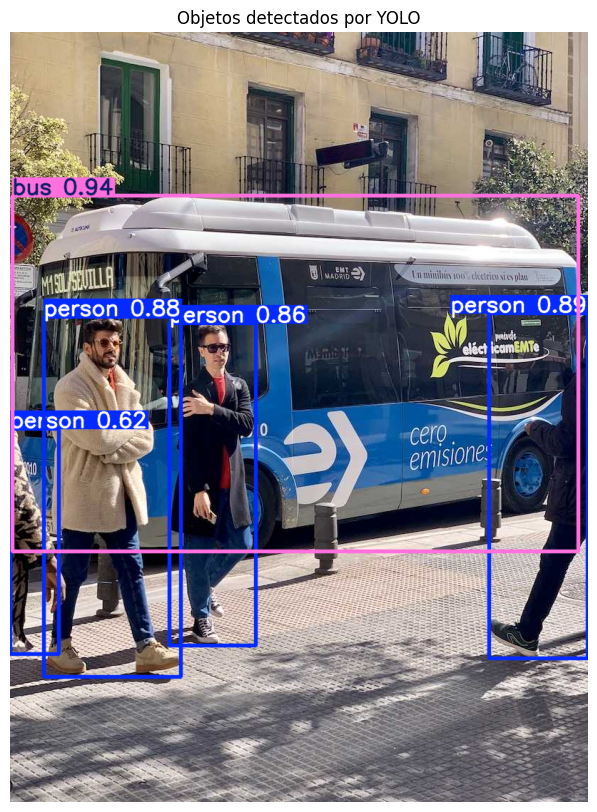

In [5]:

resultados = modelo('https://ultralytics.com/images/bus.jpg')


resultado = resultados[0]
imagen_anotada = resultado.plot()       

plt.figure(figsize=(8, 10))
plt.imshow(imagen_anotada[:, :, ::-1])  
plt.axis('off')
plt.title('Objetos detectados por YOLO')
plt.show()

## ¿Qué ha detectado exactamente?

El resultado contiene, para cada objeto: la **clase**, la **confianza**
(de 0 a 1) y las coordenadas de la **caja**. Vamos a listarlo.

In [5]:
cajas = resultado.boxes
print(f'Se han detectado {len(cajas)} objetos:\n')

for caja in cajas:
    clase_id = int(caja.cls[0])
    nombre   = modelo.names[clase_id]
    confianza = float(caja.conf[0])
    x1, y1, x2, y2 = caja.xyxy[0].tolist()
    print(f'  {nombre:12s}  confianza: {confianza:.0%}  '
          f'caja: ({x1:.0f}, {y1:.0f}) - ({x2:.0f}, {y2:.0f})')

Se han detectado 5 objetos:

  bus           confianza: 94%  caja: (4, 229) - (796, 728)
  person        confianza: 89%  caja: (671, 395) - (810, 879)
  person        confianza: 88%  caja: (47, 400) - (239, 904)
  person        confianza: 86%  caja: (223, 409) - (344, 860)
  person        confianza: 62%  caja: (0, 556) - (69, 872)
